# Redes Neurais — Semana 5 • Aula 2
## Experimento guiado: quando o treinamento começa a enganar?

**Objetivo:** observar, em uma rede neural simples, a diferença entre o comportamento nos **dados de treinamento** e nos **dados de validação**.

> **Você não precisa programar.** Execute as células na ordem e concentre-se nos gráficos e nas evidências.

### Pergunta-guia
**Um erro cada vez menor durante o treinamento significa que o modelo também funcionará bem com dados que ainda não viu?**


## Como realizar o experimento

1. Execute a próxima célula.
2. Observe as duas curvas do gráfico.
3. Localize o ponto em que o comportamento da validação deixa de acompanhar o treinamento.
4. Responda às questões de interpretação no caderno ou no AVA.




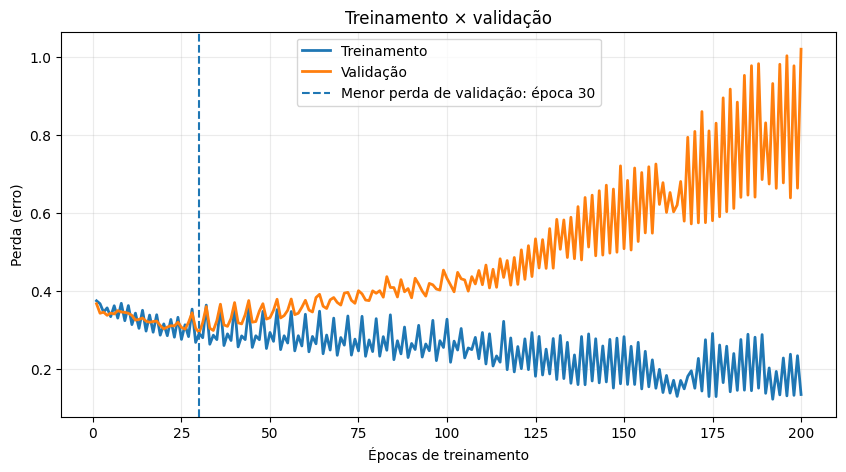

Menor perda de validação ocorreu aproximadamente na época 30.
Observe o que acontece com as duas curvas depois desse ponto.


In [ ]:

# EXPERIMENTO GUIADO — não é necessário alterar este código.

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import log_loss
from sklearn.exceptions import ConvergenceWarning

# 1) Criamos um pequeno conjunto de dados simulado.
# O conjunto é propositalmente pequeno e com ruído para tornar o fenômeno visível.
X, y = make_moons(n_samples=500, noise=0.35, random_state=4)

# 2) Separamos poucos exemplos para treinamento e muitos para validação.
X_treino, X_valid, y_treino, y_valid = train_test_split(
    X, y,
    train_size=80,
    stratify=y,
    random_state=3
)

# 3) Padronização dos dados.
scaler = StandardScaler()
X_treino = scaler.fit_transform(X_treino)
X_valid = scaler.transform(X_valid)

# 4) Rede neural com capacidade suficiente para se ajustar bastante ao pequeno conjunto de treino.
modelo = MLPClassifier(
    hidden_layer_sizes=(128, 128),
    activation="relu",
    solver="adam",
    alpha=1e-8,
    learning_rate_init=0.01,
    batch_size=32,
    max_iter=1,
    warm_start=True,
    random_state=7
)

perda_treino = []
perda_valid = []
epocas = 200

with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)

    for _ in range(epocas):
        modelo.fit(X_treino, y_treino)

        prob_treino = modelo.predict_proba(X_treino)
        prob_valid = modelo.predict_proba(X_valid)

        perda_treino.append(
            log_loss(y_treino, prob_treino, labels=[0, 1])
        )
        perda_valid.append(
            log_loss(y_valid, prob_valid, labels=[0, 1])
        )

# 5) Identificamos o melhor ponto de validação apenas para facilitar a observação.
melhor_epoca = int(np.argmin(perda_valid)) + 1

# 6) Gráfico
plt.figure(figsize=(10, 5))
plt.plot(range(1, epocas + 1), perda_treino, linewidth=2, label="Treinamento")
plt.plot(range(1, epocas + 1), perda_valid, linewidth=2, label="Validação")
plt.axvline(melhor_epoca, linestyle="--", linewidth=1.5, label=f"Menor perda de validação: época {melhor_epoca}")

plt.xlabel("Épocas de treinamento")
plt.ylabel("Perda (erro)")
plt.title("Treinamento × validação")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

print(f"Menor perda de validação ocorreu aproximadamente na época {melhor_epoca}.")
print("Observe o que acontece com as duas curvas depois desse ponto.")


## Observe antes de continuar

Converse com um colega e responda:

1. **O que acontece com a perda do treinamento ao longo das épocas?**
2. **A perda da validação acompanha o treinamento durante todo o processo?**
3. **O que acontece depois do ponto em que a validação apresenta seu melhor resultado?**
4. **O modelo continua melhorando para todos os dados ou principalmente para os dados usados no treinamento?**

> Não procure ainda uma definição. Primeiro descreva **o que o gráfico mostra**.


In [ ]:

# RESUMO DAS EVIDÊNCIAS — não altere.

pontos = sorted(set([
    1,
    max(2, melhor_epoca // 2),
    melhor_epoca,
    min(epocas, melhor_epoca + 40),
    epocas
]))

resumo = pd.DataFrame({
    "Época": pontos,
    "Perda no treinamento": [perda_treino[i-1] for i in pontos],
    "Perda na validação": [perda_valid[i-1] for i in pontos]
})

resumo["Perda no treinamento"] = resumo["Perda no treinamento"].round(3)
resumo["Perda na validação"] = resumo["Perda na validação"].round(3)

display(resumo)

print("Use a tabela como evidência para justificar sua resposta.")


,Época,Perda no treinamento,Perda na validação
0,1,0.375,0.368
1,15,0.298,0.323
2,30,0.292,0.294
3,70,0.281,0.365
4,200,0.135,1.020


Use a tabela como evidência para justificar sua resposta.


## Agora podemos nomear o fenômeno

### Overfitting
Ocorre quando o modelo se ajusta excessivamente aos dados de treinamento e **não mantém o mesmo desempenho diante de dados novos**.

### Generalização
É a capacidade de o modelo manter bom desempenho diante de dados diferentes daqueles utilizados diretamente para ajustar seus parâmetros.

### Conecte com o gráfico
No experimento, procure a região em que:

**perda do treinamento continua diminuindo**  
enquanto  
**perda da validação começa a aumentar**

Essa divergência fornece **evidências de overfitting**.

> **Ideia importante:** melhorar no treinamento não significa, necessariamente, melhorar a capacidade de lidar com dados novos.


## Registro final

Complete com suas próprias palavras:

**1. Há evidências de overfitting quando...**

....................................................................................................................

**2. A validação é importante porque...**

....................................................................................................................

**3. Reduzir apenas o erro do treinamento não é suficiente porque...**

....................................................................................................................

### Próximo passo da aula
Agora que identificamos o problema, precisamos responder:

**Como podemos controlar o ajuste excessivo do modelo?**

É aí que entram as **técnicas de regularização**.


---
### Observação didática
Os dados deste experimento são **simulados** e foram configurados para tornar o comportamento de overfitting visível em poucos segundos. O objetivo é **interpretar evidências**, e não aprender programação nesta aula.
